In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/cv-3-segmentation.zip'
extract_path = '/content/cv-3-segmentation'

os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
%pip install torchvision torchinfo albumentations segmentation_models_pytorch

In [13]:
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import datasets
from torchvision.transforms import v2 as T

import albumentations as A
from albumentations.pytorch import ToTensorV2

from torchinfo import summary

from tqdm.notebook import tqdm

import pandas as pd
import numpy as np

import segmentation_models_pytorch as smp

import os
from typing import final
from pathlib import Path
from PIL import Image
from IPython.display import clear_output

from matplotlib import pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [14]:
def preprocess_mask(mask):
    mask = np.asarray(mask).astype(np.float32)
    mask[mask == 2.0] = 0.0
    mask[(mask == 1.0) | (mask == 3.0)] = 1.0
    return mask
    
@final
class AnimalsTrainDataset(Dataset):
    def __init__(self, directory: Path | str, transforms):
        self.directory = Path(directory)
        self.ids: list[str] = [p.stem for p in (self.directory / "images").iterdir()]
        self.transforms = transforms

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx: int):

        image_path = self.directory / "images" / (self.ids[idx] + ".jpg")
        image = np.asarray(Image.open(image_path).convert("RGB"))

        mask_path = self.directory / "masks" / (self.ids[idx] + ".png")
        mask = preprocess_mask(Image.open(mask_path))

        transforms = self.transforms(image=image, mask=mask)
        image = transforms["image"]
        mask = transforms["mask"]

        return image, mask
        
class AnimalsTestDataset(Dataset):
    def __init__(self, directory: Path | str, transforms):
        self.directory = Path(directory)
        self.images: list[str] = os.listdir(self.directory / "images")
        self.transforms = transforms

    def __len__(self):
        return len(self.images)
        
    def __getitem__(self, idx: int):
        image_path = self.directory / "images" / self.images[idx]
        image = np.asarray(Image.open(image_path))

        transforms = self.transforms(image=image)
        image = transforms["image"]

        return image, self.images[idx]

In [16]:
IMG_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.8),
    A.RandomBrightnessContrast(p=0.5),
    A.GridDistortion(p=0.2),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    ToTensorV2(),
])

whole_train_dataset = AnimalsTrainDataset("./cv-3-segmentation/train/", train_transform)
test_dataset = AnimalsTestDataset("./cv-3-segmentation/test/", test_transform)

In [17]:
BATCH_SIZE = 32
train_len = int(len(whole_train_dataset) * 0.8)
val_len = len(whole_train_dataset) - train_len
train_dataset, val_dataset = random_split(whole_train_dataset, [train_len, val_len])

train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False)

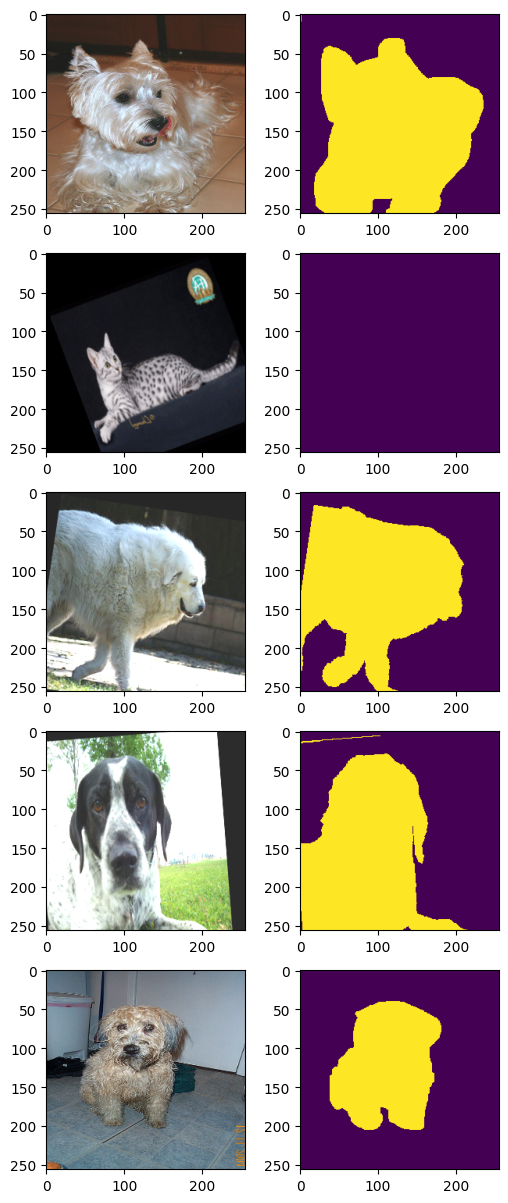

In [18]:
to_pil = T.ToPILImage()

pairs_num = 5

plt.figure(figsize=(6, pairs_num * 3))
for i, (x, y) in enumerate(train_loader):
    if i == pairs_num:
        break
    plt.subplot(pairs_num, 2, i * 2 + 1)
    plt.imshow(to_pil(x[i]))
    plt.subplot(pairs_num, 2, i * 2 + 2)
    plt.imshow(to_pil(y[i]))

In [6]:
from dataclasses import dataclass, field
from matplotlib import pyplot as plt

@dataclass
class AccLossLog:
    acc: float
    loss: float

@dataclass
class History:
    train: list[AccLossLog] = field(default_factory=list)
    test: list[AccLossLog] = field(default_factory=list)

    def append(self, train_log: AccLossLog, test_log: AccLossLog):
        self.train.append(train_log)
        self.test.append(test_log)
        assert len(self.train) == len(self.test)

    def __len__(self):
        return len(self.train)

    def get_train_accs(self):
        return [log.acc for log in self.train]

    def get_test_accs(self):
        return [log.acc for log in self.test]

    def get_train_losses(self):
        return [log.loss for log in self.train]

    def get_test_losses(self):
        return [log.loss for log in self.test]

    def plot(self):
        """Строит графики точности и loss для train и test"""
        epochs = range(1, len(self) + 1)
        plt.figure(figsize=(12,5))

        # Accuracy
        plt.subplot(1,2,1)
        plt.plot(epochs, self.get_train_accs(), 'b-', label='Train Acc')
        plt.plot(epochs, self.get_test_accs(), 'r-', label='Test Acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Accuracy per Epoch')
        plt.legend()
        plt.grid()

        # Loss
        plt.subplot(1,2,2)
        plt.plot(epochs, self.get_train_losses(), 'b-', label='Train Loss')
        plt.plot(epochs, self.get_test_losses(), 'r-', label='Test Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss per Epoch')
        plt.legend()
        plt.grid()

        plt.tight_layout()
        plt.show()


In [ ]:
def accuracy(prediction: torch.Tensor, target: torch.Tensor) -> float:
    prediction = torch.squeeze(prediction, dim=1)

    tp, fp, fn, tn = smp.metrics.get_stats(prediction, target.long(), mode='binary', threshold=0.5)
    iou_score = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro")
    # accuracy = smp.metrics.accuracy(tp, fp, fn, tn, reduction="macro")

    return iou_score.item()

def do_train_step(
    model: nn.Module,
    train_loader: DataLoader[torch.Tensor],
    loss_fn: nn.Module,
    optim: torch.optim.Optimizer,
    device: str
) -> tuple[float, float]:
    model = model.to(device)
    model.train()

    train_loss = train_acc = 0
    with tqdm(train_loader, desc="Train", leave=False) as train_bar:
        for x, y in train_bar:
            x = x.float().to(device)
            y = y.float().to(device)

            optim.zero_grad()

            prob = model(x)
            pred = (prob.sigmoid() > 0.5).float()

            loss = loss_fn(prob, y)

            loss.backward()
            optim.step()

            train_loss += loss.item()
            train_acc += accuracy(pred, y)

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)

    return train_acc, train_loss

@torch.inference_mode()
def do_test_step(
    model: nn.Module,
    test_loader: DataLoader[torch.Tensor],
    loss_fn: nn.Module,
    device: str
) -> tuple[float, float]:
    model = model.to(device)
    model.eval()

    test_loss = test_acc = 0
    with tqdm(test_loader, desc="Test", leave=False) as test_bar:
        for x, y in test_bar:
            x = x.float().to(device)
            y = y.float().to(device)

            prob = model(x)
            pred = (prob.sigmoid() > 0.5).float()

            loss = loss_fn(prob, y)

            test_loss += loss.item()
            test_acc += accuracy(pred, y)

    test_loss /= len(test_loader)
    test_acc /= len(test_loader)

    return test_acc, test_loss

def train_model(
    model: nn.Module,
    train_loader: DataLoader[torch.Tensor],
    test_loader: DataLoader[torch.Tensor],
    optim: torch.optim.Optimizer,
    loss_fn: nn.Module,
    epochs: int,
    device: str,
    history: History | None = None
) -> History:
    if not history:
        history = History()

    for epoch in tqdm(range(epochs), desc="Epochs"):
        train = AccLossLog(*do_train_step(model, train_loader, loss_fn, optim, device))
        test = AccLossLog(*do_test_step(model, test_loader, loss_fn, device))
        history.append(train, test)

        clear_output(wait=True)

        history.plot()

    return history

In [8]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

In [9]:
summary(model)

Layer (type:depth-idx)                                  Param #
DeepLabV3Plus                                           --
├─ResNetEncoder: 1-1                                    --
│    └─Conv2d: 2-1                                      9,408
│    └─BatchNorm2d: 2-2                                 128
│    └─ReLU: 2-3                                        --
│    └─MaxPool2d: 2-4                                   --
│    └─Sequential: 2-5                                  --
│    │    └─BasicBlock: 3-1                             73,984
│    │    └─BasicBlock: 3-2                             73,984
│    │    └─BasicBlock: 3-3                             73,984
│    └─Sequential: 2-6                                  --
│    │    └─BasicBlock: 3-4                             230,144
│    │    └─BasicBlock: 3-5                             295,424
│    │    └─BasicBlock: 3-6                             295,424
│    │    └─BasicBlock: 3-7                             295,424
│    └─Sequenti

In [10]:
for x, y in val_loader:
    x = x.float().to(device)
    y = y.float().to(device)

    prob = model(x)
    pred = (prob > 0.5).float()
    print(accuracy(pred, y))

    break

MIOpen(HIP): Warning [IsEnoughWorkspace] [GetSolutionsFallback WTI] Solver <GemmFwdRest>, workspace required: 147456, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [EvaluateInvokers] Solver <GemmFwdRest>, workspace required: 147456, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [GetSolutionsFallback WTI] Solver <GemmFwdRest>, workspace required: 294912, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [EvaluateInvokers] Solver <GemmFwdRest>, workspace required: 294912, provided ptr: 0 size: 0


0.015672199428081512


In [11]:
trainable_parameters = filter(lambda p: p.requires_grad, model.parameters())
optim = torch.optim.AdamW(trainable_parameters, lr=1e-3)

loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True).to(device)

history = History()

In [12]:
lr = 1e-3
epochs = 5
history = train_model(model, train_loader, val_loader, optim, loss_fn, epochs, device, history)

Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/148 [00:00<?, ?it/s]

MIOpen(HIP): Warning [IsEnoughWorkspace] [GetSolutionsFallback WTI] Solver <GemmBwdRest>, workspace required: 294912, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [EvaluateInvokers] Solver <GemmBwdRest>, workspace required: 294912, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [GetSolutionsFallback WTI] Solver <GemmWrwUniversal>, workspace required: 294912, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [EvaluateInvokers] Solver <GemmWrwUniversal>, workspace required: 294912, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [GetSolutionsFallback WTI] Solver <GemmBwdRest>, workspace required: 147456, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [EvaluateInvokers] Solver <GemmBwdRest>, workspace required: 147456, provided ptr: 0 size: 0
MIOpen(HIP): Warning [IsEnoughWorkspace] [GetSolutionsFallback WTI] Solver <GemmWrwUniversal>, workspace required: 147456, provided ptr: 0 size: 0
MIOpen(HIP): Wa

KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), "model_e1.pt")

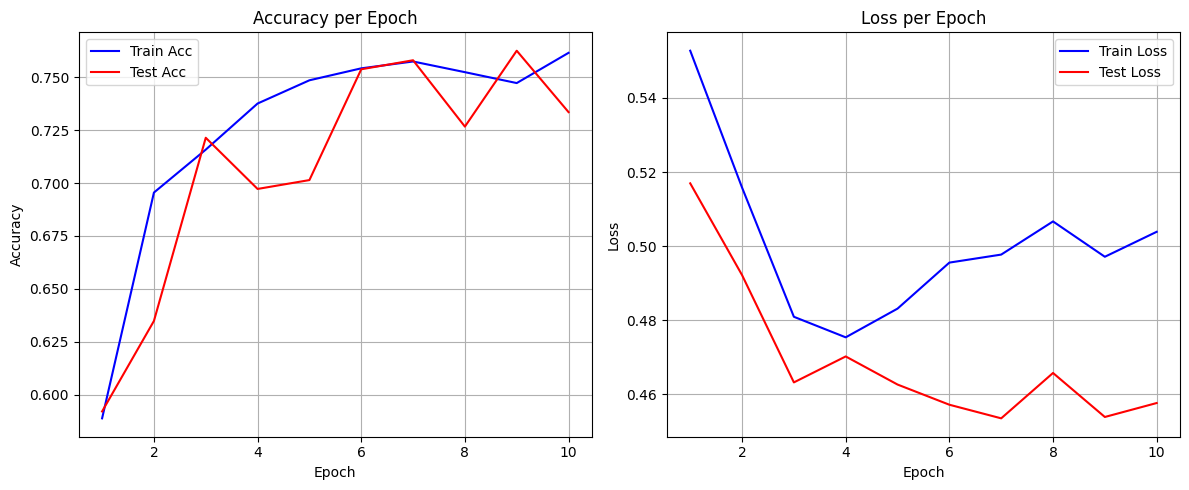

In [ ]:
lr = 1e-4
history = train_model(model, train_loader, val_loader, optim, loss_fn, epochs, device, history)

In [28]:
torch.save(model.state_dict(), "model_e2.pt")

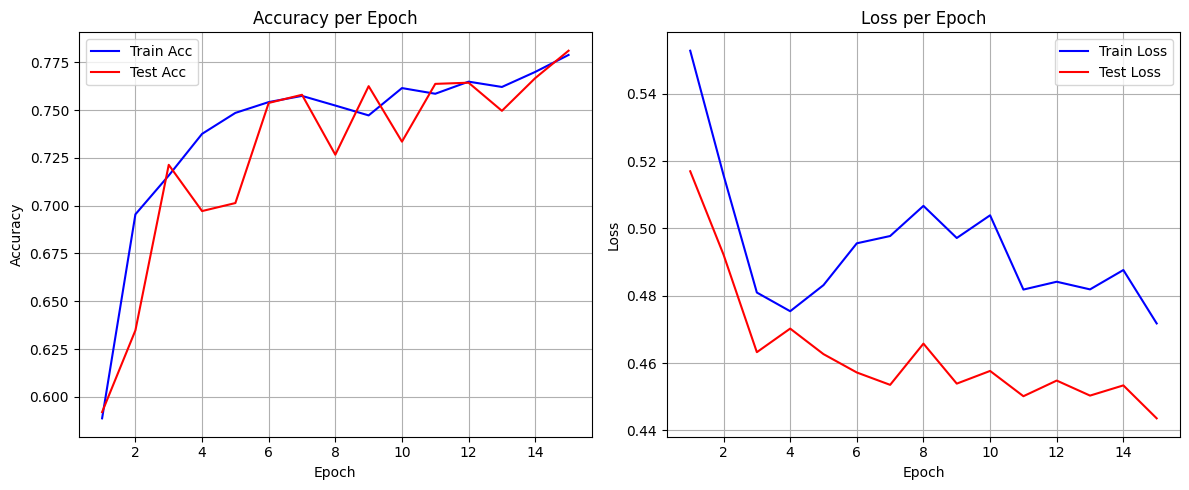

In [ ]:
lr = 1e-5
history = train_model(model, train_loader, val_loader, optim, loss_fn, epochs, device, history)

In [30]:
torch.save(model.state_dict(), "model_e3.pt")

In [30]:
def rle_encode_tensor(mask_tensor):
    """
    Encode a PyTorch binary mask tensor into Kaggle-style RLE string.
    
    Args:
        mask_tensor: torch.Tensor of shape (H, W) or (1, H, W)
                     dtype: bool, int, or float (will be thresholded at 0.5 if float)
    
    Returns:
        str: RLE string (e.g., "1 3 10 5 ...") or empty string if no foreground
    """
    # Убираем лишние измерения
    if mask_tensor.ndim == 3:
        if mask_tensor.shape[0] == 1:
            mask_tensor = mask_tensor.squeeze(0)
        else:
            raise ValueError("Expected single-channel mask, got shape: {}".format(mask_tensor.shape))
    
    # Переводим на CPU и в numpy
    mask = mask_tensor.detach().cpu().numpy()
    
    # Бинаризуем, если нужно
    if mask.dtype == np.float32 or mask.dtype == np.float64:
        mask = mask > 0.5
    else:
        mask = mask.astype(bool)
    
    # Проверка на пустую маску
    if mask.sum() == 0:
        return ""
    
    # RLE в column-major порядке (Kaggle стандарт)
    pixels = mask.T.flatten()  # <-- ВАЖНО: .T для column-major
    pixels = np.concatenate([[0], pixels, [0]])  # паддинг
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    
    return ' '.join(str(x) for x in runs)


def rle_decode(rle_string: str, shape: tuple) -> np.ndarray:
    """
    Decode a Kaggle-style RLE string into a binary mask.

    Args:
        rle_string (str): RLE string like "10 5 20 8" (start1 len1 start2 len2 ...)
        shape (tuple): (height, width) of the output mask

    Returns:
        np.ndarray: Binary mask of shape (height, width), dtype=np.uint8
    """
    if not rle_string or rle_string == "-1" or rle_string.strip() == "":
        return np.zeros(shape, dtype=np.uint8)

    rle = np.array(rle_string.split(), dtype=int)
    starts = rle[0::2] - 1  # Convert from 1-indexed to 0-indexed
    lengths = rle[1::2]

    flat_mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    for start, length in zip(starts, lengths):
        flat_mask[start : start + length] = 1

    mask = flat_mask.reshape(shape)
    return mask

def inference(model, img):
    tensor_img = test_transform(image=img)['image']
    tensor_int = tensor_img.unsqueeze(0).float().to(device)
    tensor_mask = torch.sigmoid(model(tensor_int))
    y_mask = tensor_mask[0].detach().cpu().numpy()[0]
    y_mask[y_mask>0.5] = 1.
    y_mask[y_mask<=0.5] = 0.
    return y_mask

In [ ]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=1
).to(device)

model.load_state_dict(torch.load("./model_e3.pt"))

<All keys matched successfully>

In [32]:
import cv2

ious = []
path2image = Path("./cv-3-segmentation/test/images/")
all_masks = []

model.eval()
for f in path2image.glob("*"):
    if f.is_file():
        img = np.asarray(Image.open(f).convert("RGB"))
        
        original_shape = img.shape[:2]
        y_pred_binary_128 = inference(model, img) 
        y_pred_final = cv2.resize(
            y_pred_binary_128, 
            (original_shape[1], original_shape[0]), 
            interpolation=cv2.INTER_NEAREST
        ).astype(np.uint8)
        s = rle_encode_tensor(torch.tensor(y_pred_final))
        
        all_masks.append({"FILE_NAME":f.name,
                          "TARGET":s})

In [33]:
pd.DataFrame(all_masks).to_csv("Mishin_Timofey_submission.csv", index = False)